# Color Cell IDs

Given an Excel spreadsheet indicating the cell type of each ID, a plot will be made of the tissue cross-section, where each cell type will have a different color.

The Excel spreadsheet must have one cell-type per column. Then each column will indicate the IDs to color. It is ok if different columns have different number of IDs. The column must also indicate the color corresponding to the cell type.

The background in the output figure will be white. Cells whose IDs was not indicated in any column will be colored gray.

In [1]:
import numpy as np
import pandas as pd
from matplotlib import pyplot as plt
import matplotlib as mpl
import tifffile as tf
import os
import utils

from scipy import ndimage, spatial,stats
from mpl_toolkits.axes_grid1.anchored_artists import AnchoredSizeBar

rng = np.random.default_rng(42)
nudge = rng.uniform(-0.15, 0.15, 10000)


axisoff = dict(labelleft=False, left=False, bottom=False, labelbottom=False)
sbkw1 = dict(label='', size=100, loc='upper left', pad=0.5, color='thistle', frameon=False, size_vertical=10)
viridis = mpl.colormaps['viridis'].resampled(4)
viridis = mpl.colormaps['RdYlBu'].resampled(9)

dst = os.pardir + os.sep + 'overlaps' + os.sep
dpi = 300
fs = 13.5
fmt = '.png'
savefigkw = dict(dpi=dpi, format=fmt[1:], bbox_inches='tight')

fmt2 = '.pdf'
savefigkw2 = dict(dpi=96, format=fmt2[1:], bbox_inches='tight')

In [170]:
def signifval(pvalue):
    if pvalue >= 0.01:
        return 0
    elif (pvalue < 0.01) and (pvalue >= 0.001):
        return 1
    elif (pvalue < 0.001) and (pvalue >= 0.0001):
        return 2
    else:
        return 3
        
def tukey_hsd(*args, equal_var=True):

    ntreatments = len(args)
    means = np.asarray([np.mean(arg) for arg in args])
    nsamples_treatments = np.asarray([a.size for a in args])
    nobs = np.sum(nsamples_treatments)
    vars_ = np.asarray([np.var(arg, ddof=1) for arg in args])

    if equal_var:
        # determine mean square error [5]. Note that this is sometimes called
        # mean square error within.
        mse = (np.sum(vars_ * (nsamples_treatments - 1)) / (nobs - ntreatments))

        # The calculation of the standard error differs when treatments differ in
        # size. See ("Unequal sample sizes")[1].
        if np.unique(nsamples_treatments).size == 1:
            # all input groups are the same length, so only one value needs to be
            # calculated [1].
            normalize = 2 / nsamples_treatments[0]
        else:
            # to compare groups of differing sizes, we must compute a variance
            # value for each individual comparison. Use broadcasting to get the
            # resulting matrix. [3], verified against [4] (page 308).
            normalize = 1 / nsamples_treatments + 1 / nsamples_treatments[None].T

        # the standard error is used in the computation of the tukey criterion and
        # finding the p-values.
        stand_err = np.sqrt(normalize * mse / 2)
        df = nobs - ntreatments
    else:
        # `stand_err` is the denominator of the Behrens-Fisher statistic ($v$)
        # with a factor of $\sqrt{2}$. Compare [7] p.116 "t-solution rejects H0 if...",
        # [7] p. 117 "H0 was rejected", and definition of `t_stat` below.
        sj2_nj = vars_ / nsamples_treatments
        si2_ni = sj2_nj[:, np.newaxis]
        stand_err = np.sqrt(si2_ni + sj2_nj) / 2**0.5

        # `df` is the Welch degree of freedom $\nu$.
        # See [7] p. 116 "and the degrees of freedom, $\nu$, are given by...".
        njm1 = nsamples_treatments - 1
        nim1 = njm1[:, np.newaxis]
        df = (si2_ni + sj2_nj)**2 / (si2_ni**2 / nim1 + sj2_nj**2 / njm1)

    # the mean difference is the test statistic.
    mean_differences = means[None].T - means

    # Calculate the t-statistic to use within the survival function of the
    # studentized range to get the p-value.
    t_stat = np.abs(mean_differences) / stand_err

    params = t_stat, ntreatments, df
    pvalues = stats.studentized_range.sf(*params)

    return stats._hypotests.TukeyHSDResult(mean_differences, pvalues, ntreatments, df, stand_err)

In [2]:
sample = 'D2'

wsrc = os.pardir + os.sep + 'cell_dams' + os.sep
#csrc = os.pardir + os.sep + 'data' + os.sep
#ksrc = os.pardir + os.sep + 'kde' + os.sep + sample + os.sep

wall = tf.imread(wsrc + sample + '_dams.tif').astype(bool)
wcoords = np.asarray(np.nonzero(~wall))
wallshape = wall.shape
label, cellnum = ndimage.label(wall, ndimage.generate_binary_structure(2,1))
label[label == 1] = 0
css = ndimage.find_objects(label)

ksrc = os.pardir + os.sep + 'kde' + os.sep + sample + os.sep
metacell = pd.read_csv(ksrc + sample + '_cells_metadata.csv', index_col = 'ndimage_cellID')
wc = np.loadtxt(ksrc + sample + '_icoords.csv', delimiter=',', dtype=int)
wc = wc[:, ~np.all(wc%50, axis=0)]
metaecc = pd.read_csv(ksrc + sample + '_nodule_root_eccentricity.csv', index_col='ndimage_cellID')
transcell = pd.read_csv(ksrc + sample + '_transcells_metadata_w_nucleus.csv', index_col='gene').rename(columns=int)
transcriptomes = np.asarray(transcell.index, dtype=str)
print(metacell.shape)
metacell.head()

(2937, 19)


,x0,x1,y0,y1,length,height,total_area,nuclei_area,cyto_area,c2t_area_ratio,orig_comX,orig_comY,ndimage_comX,ndimage_comY,orig_cellID,number_nuclei,total_volume,cyto_volume,nuclei_volume
ndimage_cellID,,,,,,,,,,,,,,,,,,,
1,0,17152,0,17152,17152,17152,114911591,36950,114874641,0.999678,7865.12,8160.49,7865.56,8160.76,1,0,4711375231,4709860281,1514950
2,8333,8935,1293,1979,602,686,222903,1351,221552,0.993939,8635.46,1576.65,8635.18,1577.03,2,1,9139023,9083632,55391
3,8893,9151,1317,1598,258,281,42604,0,42604,1.000000,9013.47,1470.26,9013.07,1469.69,3,0,1746764,1746764,0
4,10790,11221,1337,1591,431,254,77463,0,77463,1.000000,10999.04,1460.48,10998.62,1459.99,4,0,3175983,3175983,0
5,7740,8048,1362,1823,308,461,86041,870,85171,0.989889,7894.78,1596.06,7894.19,1595.83,5,1,3527681,3492011,35670


In [3]:
translocs = [None for _ in range(len(transcriptomes))]
src = os.pardir + os.sep + 'Bacteria Info for Erik' + os.sep
for i in range(len(transcriptomes)):
    filename = src + transcriptomes[i] + '_v2.txt'
    translocs[i] = pd.read_csv(filename, sep='\t')
tlocs = pd.concat(translocs)
tsutton = utils.generate_transcell_metadata(translocs, transcriptomes, cellnum, label).set_index('gene')

In [4]:
combined = tf.imread(wsrc + 'FINAL_cell_nuc_merged_uint32.tif')
combareas, _ = np.histogram(combined.ravel(), bins=np.arange(combined.max() + 2))

#noms = np.flip(np.asarray(ndimage.center_of_mass(lzw, lzw, range(1, lzw.max()+1))), axis=1)
#dists = spatial.distance.cdist(noms, metacell[['ndimage_comX','ndimage_comY']],  metric='euclidean')

In [5]:
nsrc = os.pardir + os.sep + 'nuclear_mask' + os.sep
nuclei = tf.imread(nsrc + sample + '_EDT.tif') < 1
lnuc, nnuc = ndimage.label(nuclei, ndimage.generate_binary_structure(2,1))
ns = ndimage.find_objects(lnuc)
nuc_area, _ = np.histogram(lnuc, bins=np.arange(nnuc + 2))
nuc_area[0] = 0
print('Detected',nnuc,'nuclei')

ynuclei = tf.imread(nsrc + 'FINAL_nuclei.tif')
ys = ndimage.find_objects(ynuclei)
ynuc_area, _ = np.histogram(ynuclei, bins=np.arange(ynuclei.max() + 2))
ynuc_area[0] = 0
print('Detected', ynuclei.max(),'nuclei')

Detected 1365 nuclei
Detected 2237 nuclei


In [6]:
lsutton = 'Tennant et al (2026)'
lyaohua = 'This Paper'

In [7]:
ymethod = 'combined'
lzw = combined
newarea = combareas


#ymethod = 'nuclear'
#lzw = ynuclei
#newarea = ynuc_area

#ymethod = 'n2n'
#lzw = ynuclei
#newarea = ynuc_area
#label = lnuc
#nss = ns



nss = ndimage.find_objects(lzw)
tyaohua = utils.generate_transcell_metadata(translocs, transcriptomes, lzw.max(), lzw).set_index('gene')

# Actual analyses



In [8]:
overlaps = dict()
overdf = pd.DataFrame(0., index=range(1,1+len(nss)), columns=['putative','TP','FP','FN','IoU', 'precision','recall','f1'])

for ix in overdf.index:
    newcell = lzw[nss[ix-1]] == ix
    intersect = label[nss[ix-1]][newcell]
    uq, ct = np.unique(intersect, return_counts=True)
    overlaps[ix] = np.vstack((uq[uq > 0], ct[uq > 0]))
    
    if overlaps[ix].shape[1] > 0:
        
        putative = overlaps[ix][0][ np.argmax(overlaps[ix][1]) ]
        
        overdf.loc[ix, 'putative'] = putative
        overdf.loc[ix, 'TP']  = overlaps[ix][1].max()
        overdf.loc[ix, 'FP'] = newarea[ix] - overdf.loc[ix, 'TP']
        overdf.loc[ix, 'FN'] = metacell.loc[putative, 'total_area'] - overdf.loc[ix, 'TP']
        overdf.loc[ix, 'IoU'] = overdf.loc[ix, 'TP']/overdf.loc[ix, ['TP','FP','FN']].sum()
        overdf.loc[ix, 'precision'] = overdf.loc[ix, 'TP']/newarea[ix]
        overdf.loc[ix, 'recall'] = overdf.loc[ix, 'TP']/metacell.loc[putative, 'total_area']
        

f1 = 2*overdf['precision']*overdf['recall']/(overdf['precision'] + overdf['recall'])
f1 = f1.fillna(0)
overdf['f1'] = f1
foo = ['putative', 'TP', 'FP', 'FN']
overdf = overdf.astype(dict(zip(foo, [int for _ in foo])))
matched = overdf.loc[overdf['putative'] > 0]

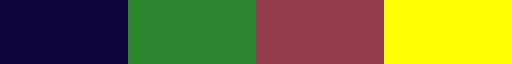

In [10]:
divcolors = ["#117733", "yellow", "#882255"]
divcmap = mpl.colors.LinearSegmentedColormap.from_list("mycmap", divcolors)
divcolors[0] = divcmap.resampled(19)(1)
divcolors[2] = divcmap.resampled(19)(17)
divcmap = mpl.colors.LinearSegmentedColormap.from_list("mycmap", divcolors)
divcmap
cmap = mpl.colors.ListedColormap(['#0E053C'] + [divcolors[i] for i in [0,2,1]])
cmap

In [18]:
matched.sort_values(by='IoU', ascending=False).head()
(matched['precision'] - matched['recall']).sort_values().head(10)
#matched[ (matched['precision'] == 1) & (matched['recall'] > 0.25) & (matched['IoU'] < 0.5)]
matched[ (matched['precision'] < 0.1) & (matched['recall'] < 0.1) ].head()

,putative,TP,FP,FN,IoU,precision,recall,f1
89,2733,382,25028,24861,0.007599,0.015033,0.015133,0.015083
102,2919,2657,54174,290991,0.007639,0.046753,0.009048,0.015162
269,2858,595,43443,99528,0.004144,0.013511,0.005943,0.008255
698,2286,1449,56223,28308,0.016853,0.025125,0.048694,0.033147
811,736,1535,35296,158635,0.007853,0.041677,0.009584,0.015584


In [135]:
for ix in matched.sort_values(by='IoU', ascending=False).head().index:
#for ix in [168, 1412, 1842, 173, 1211, 697]:
#for ix in matched[ (matched['precision'] == 1) & (matched['recall'] > 0.25) & (matched['IoU'] < 0.5)].index:
#for ix in matched[ (matched['precision'] < 0.1) & (matched['recall'] < 0.1) ].head(6).index:
    jx = matched.loc[ix, 'putative']
    ix -= 1; jx -= 1
    
    js_ = np.s_[min([nss[ix][0].start, css[jx][0].start]) : max([nss[ix][0].stop, css[jx][0].stop]) ,
                min([nss[ix][1].start, css[jx][1].start]) : max([nss[ix][1].stop, css[jx][1].stop]) ]
    extent = (js_[1].start, js_[1].stop, js_[0].start, js_[0].stop)
    gts_ = np.s_[css[jx][0].start - js_[0].start : css[jx][0].stop - js_[0].start, 
                 css[jx][1].start - js_[1].start : css[jx][1].stop - js_[1].start]
    
    news_= np.s_[nss[ix][0].start - js_[0].start : nss[ix][0].stop - js_[0].start, 
                 nss[ix][1].start - js_[1].start : nss[ix][1].stop - js_[1].start]
    
    nwjoint = np.zeros(lzw[js_].shape, dtype=int)
    gtjoint = np.zeros(lzw[js_].shape, dtype=int)
    
    nwjoint[news_] += 1*(lzw[nss[ix]] == ix+1)
    gtjoint[gts_]  += 2*(label[css[jx]] == jx+1)
    
    fig, ax = plt.subplots(1,3, figsize=(10,4), sharex=True, sharey=True)
    
    ax[0].imshow(nwjoint, vmin=0, vmax=3, origin='lower', extent=extent, cmap=cmap)
    ax[1].imshow(gtjoint, vmin=0, vmax=3, origin='lower', extent=extent, cmap=cmap);
    ax[2].imshow(nwjoint + gtjoint, vmin=0, vmax=3, origin='lower', extent=extent, cmap=cmap);
    title = [lyaohua, lsutton, 'Overlap']
    for i in range(len(ax)):
        ax[i].set_title(title[i], fontsize=fs)
        ax[i].add_artist(AnchoredSizeBar(ax[i].transData, **sbkw1))
        ax[i].tick_params(**axisoff)
    
    ax[0].set_xlabel('Cell #{:04d}'.format(ix+1), fontsize=fs)
    ax[1].set_xlabel('Cell #{:04d}'.format(metacell.loc[jx+1, 'orig_cellID']), fontsize=fs)
    ax[2].set_xlabel('P = {:.2f}; R = {:.2f}; IoU = {:.2f}'.format( *matched.loc[ix+1, ['precision', 'recall', 'IoU']] ) , fontsize=fs)
    
    fig.tight_layout()
    plt.savefig(dst+'overlap_cell_{:04d}_{}'.format(metacell.loc[jx+1, 'orig_cellID'], ymethod)+fmt, **savefigkw)
    plt.savefig(dst+'overlap_cell_{:04d}_{}'.format(metacell.loc[jx+1, 'orig_cellID'], ymethod)+fmt2, **savefigkw2)
    plt.close()
    print(ix, end=', ')

142, 152, 119, 327, 136, 

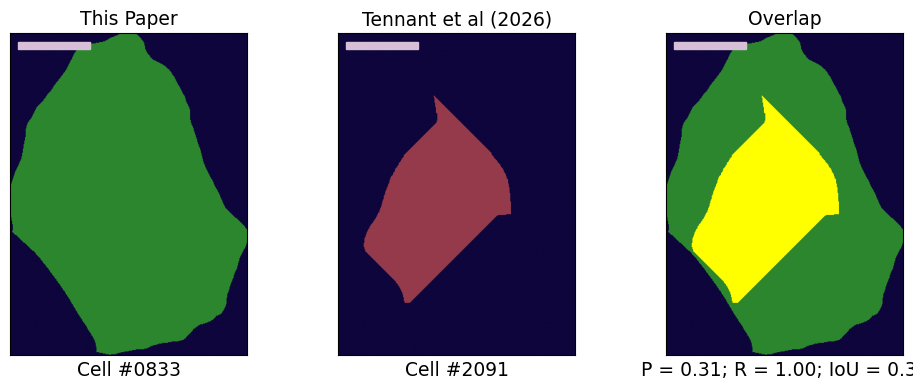

In [96]:
fig, ax = plt.subplots(1,3, figsize=(10,4), sharex=True, sharey=True)

ax[0].imshow(nwjoint, vmin=0, vmax=3, origin='lower', extent=extent, cmap=cmap)
ax[1].imshow(gtjoint, vmin=0, vmax=3, origin='lower', extent=extent, cmap=cmap);
ax[2].imshow(nwjoint + gtjoint, vmin=0, vmax=3, origin='lower', extent=extent, cmap=cmap);
title = [lyaohua, lsutton, 'Overlap']
for i in range(len(ax)):
    ax[i].set_title(title[i], fontsize=fs)
    ax[i].add_artist(AnchoredSizeBar(ax[i].transData, **sbkw1))
    ax[i].tick_params(**axisoff)

ax[0].set_xlabel('Cell #{:04d}'.format(ix+1), fontsize=fs)
ax[1].set_xlabel('Cell #{:04d}'.format(metacell.loc[jx+1, 'orig_cellID']), fontsize=fs)
ax[2].set_xlabel('P = {:.2f}; R = {:.2f}; IoU = {:.2f}'.format( *matched.loc[ix+1, ['precision', 'recall', 'IoU']] ) , fontsize=fs)

fig.tight_layout()
#plt.savefig(dst+'overlap_cell_{:04d}_{}'.format(metacell.loc[jx+1, 'orig_cellID'], ymethod)+fmt, **savefigkw)

In [11]:
unmatched = overdf[overdf['putative'] == 0]
print('There are', len(overdf) - len(unmatched), 'matched Yaohua cells')
print('There are {} [{:.1f}%] unmatched Yaohua cells'.format(len(unmatched), len(unmatched)/len(overdf)*100))

duplicated = matched[ matched['putative'].duplicated(keep=False) ]
dupidx = []
for cidx in duplicated['putative'].unique():
    # Keep all the duplicated indices minus the one with the best IoU score
    dupidx.append(matched[matched['putative'] == cidx ].sort_values('IoU').index[:-1])

dupidx = np.hstack(dupidx)
nondup = matched.drop(index=dupidx)

print('There are {} Yaohua cells in total'.format(len(overdf)))
print('There are {} [{:.1f}%] Yaohua matched to an already matched Sutton cell'.format(len(dupidx), len(dupidx)/len(overdf)*100))
print('Keeping only {} [{:.1f}%] Yaohua cells with unique Sutton-match'.format(len(nondup), len(nondup)/len(overdf)*100))
print('There are {} [{:.1f}%] Sutton cells with a unique Yaohua match'.format(len(nondup), len(nondup)/len(metacell)*100))
print('There are', len(metacell) - len(nondup), 'Sutton cells with no Yaohua match')

There are 3042 matched Yaohua cells
There are 47 [1.5%] unmatched Yaohua cells
There are 3089 Yaohua cells in total
There are 815 [26.4%] Yaohua matched to an already matched Sutton cell
Keeping only 2227 [72.1%] Yaohua cells with unique Sutton-match
There are 2227 [75.8%] Sutton cells with a unique Yaohua match
There are 710 Sutton cells with no Yaohua match


In [182]:
unmatchedidx = np.setdiff1d(range(2, len(metacell)+1), matched['putative'].unique())
duplicatedidx = duplicated['putative'].unique()
uniqueidx = np.setdiff1d(matched['putative'].unique(), duplicatedidx)
#duplicatedidx = matched.loc[dupidx, 'putative'].unique()
#uniqueidx = matched['putative'].unique()

print(unmatchedidx.shape, duplicatedidx.shape, uniqueidx.shape)

(709,) (478,) (1749,)


In [183]:
print(np.intersect1d(uniqueidx, unmatchedidx))
print(np.intersect1d(duplicatedidx, unmatchedidx))
print(np.intersect1d(uniqueidx, duplicatedidx))
foo = [ unmatchedidx, duplicatedidx, uniqueidx]
print(list(map(len,foo)))
print(sum(list(map(len,foo))) , len(metacell)-1)
print(list(map(min,foo)))
print(list(map(max,foo)))

[]
[]
[]
[709, 478, 1749]
2936 2936
[3, 5, 2]
[2935, 2936, 2937]


In [98]:
print(tukey_hsd(*yvals, equal_var=False))

Tukey's HSD Pairwise Group Comparisons (95.0% Confidence Interval)
Comparison  Statistic  p-value  Lower CI  Upper CI
 (0 - 1)    -60.792     0.000   -70.212   -51.372
 (0 - 2)    -25.413     0.000   -28.968   -21.858
 (1 - 0)     60.792     0.000    51.372    70.212
 (1 - 2)     35.379     0.000    25.960    44.798
 (2 - 0)     25.413     0.000    21.858    28.968
 (2 - 1)    -35.379     0.000   -44.798   -25.960



In [103]:
print(tukey_hsd(*yvals, equal_var=False))

Tukey's HSD Pairwise Group Comparisons (95.0% Confidence Interval)
Comparison  Statistic  p-value  Lower CI  Upper CI
 (0 - 1)     -1.195     0.000    -1.425    -0.964
 (0 - 2)     -1.221     0.000    -1.342    -1.100
 (1 - 0)      1.195     0.000     0.964     1.425
 (1 - 2)     -0.027     0.966    -0.274     0.221
 (2 - 0)      1.221     0.000     1.100     1.342
 (2 - 1)      0.027     0.966    -0.221     0.274



844.544
12.423


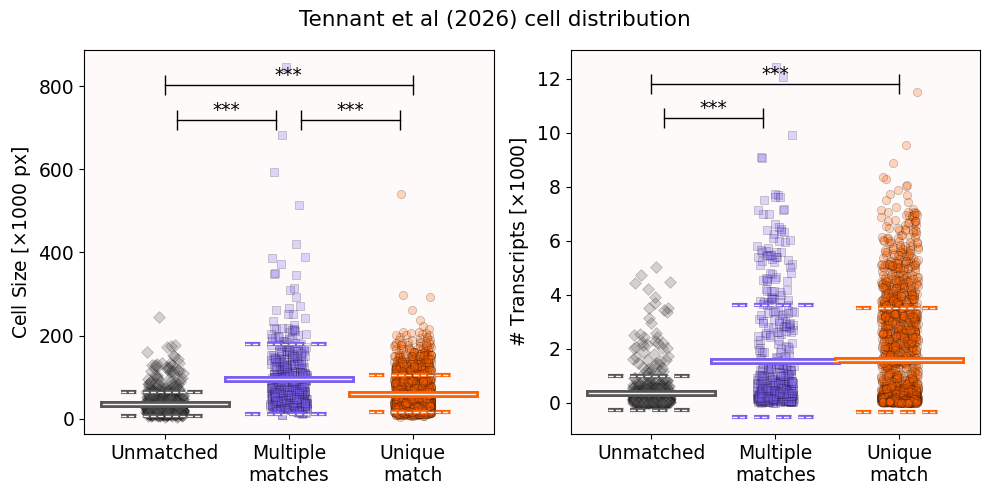

In [164]:
idxlabel = ['Unmatched', 'Multiple\nmatches', 'Unique\nmatch']
wong = ['#555555', '#785EF0', '#FE6100', '#DC267F']
marker = ['D' , 's', 'o']
y = [metacell['total_area']/1000, tsutton.sum(axis=0)/1000]

fig, ax = plt.subplots(1,2, figsize=(10,5), sharex=True)

for j in range(2):

    yvals = []
    ax[j].set_facecolor('snow')
    ax[j].set_xticks(range(len(foo)), idxlabel)
    ax[j].tick_params(labelsize=fs)
    for i in range(len(foo)):
        #yval = metacell.loc[foo[i], 'total_area']/1000
        #yval = tsutton[foo[i]].sum(axis=0)/1000
        yval = y[j].loc[foo[i]]
        
        mean = yval.mean()
        sem = yval.std()
        ax[j].scatter(i + nudge[:len(yval)], yval, c=wong[i], marker=marker[i], ec='k', lw=0.5, alpha=0.25, zorder=1)
        ax[j].plot([-0.5 + i, 0.5 +i], [mean, mean], c=wong[i], lw=5, zorder=2)
        ax[j].plot([-0.5 + i, 0.5 +i], [mean, mean], c='whitesmoke', lw=1, zorder=3)
        
        ax[j].plot([-0.35 + i, 0.35 +i], [mean+sem, mean+sem], c=wong[i], ls='dashed', lw=3, zorder=2)
        ax[j].plot([-0.35 + i, 0.35 +i], [mean+sem, mean+sem], c='whitesmoke', ls='dashed', lw=1, zorder=3)
    
        ax[j].plot([-0.35 + i, 0.35 +i], [mean-sem, mean-sem], c=wong[i], ls='dashed', lw=3, zorder=2)
        ax[j].plot([-0.35 + i, 0.35 +i], [mean-sem, mean-sem], c='whitesmoke', ls='dashed', lw=1, zorder=3)
    
        yvals.append(yval)
        
        #ax[j].set_yscale('log',base=10)
    ymax = max(list(map(max, yvals)))
    print(ymax)
    ax[j].plot([0,2],[0.95*ymax, 0.95*ymax], c='k', lw=1, marker='|', mew=1, ms=15)
    ax[j].plot([0.1,0.9],[0.85*ymax, 0.85*ymax], c='k', lw=1, marker='|', mew=1, ms=15)
    ax[j].text(1,0.95*ymax,'***',ha='center', va='bottom', fontsize=fs)
    ax[j].text(0.5,0.85*ymax,'***',ha='center', va='bottom', fontsize=fs)

ymax = 844.544
ax[0].set_ylabel('Cell Size [$\\times$1000 px]', fontsize=fs)
ax[0].plot([1.1, 1.9],[0.85*ymax, 0.85*ymax], c='k', lw=1, marker='|', mew=1, ms=15)
ax[0].text(1.5,0.85*ymax,'***',ha='center', va='bottom', fontsize=fs)

ax[1].set_ylabel('# Transcripts [$\\times$1000]', fontsize=fs)

    
fig.suptitle(lsutton + ' cell distribution', fontsize=1.15*fs)
fig.tight_layout()

plt.savefig(dst+'matched_cell_distribution_'+ymethod+fmt, **savefigkw)
plt.savefig(dst+'matched_cell_distribution_'+ymethod+fmt2, **savefigkw2)

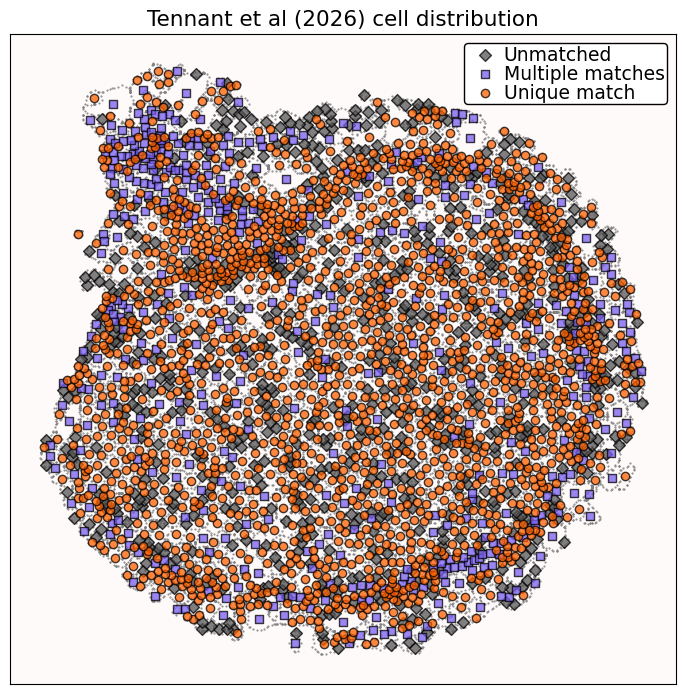

In [165]:
w = wcoords[:, ~np.all(wcoords%50, axis=0)]

fig,ax = plt.subplots(1,1,figsize=(7,7), sharex=True, sharey=True)
ax = np.atleast_1d(ax); i = 0

ax[i].set_facecolor('snow')
ax[i].scatter(w[1], w[0], marker='.', s=1, c='gray', zorder=1)
ax[i].tick_params(**axisoff)
ax[i].set_aspect('equal')
ax[i].set_title(lsutton + ' cell distribution', fontsize=1.15*fs)    
for i in range(len(marker)):
    ax[0].scatter(*metacell.loc[foo[i], ['ndimage_comX', 'ndimage_comY']].T.values, marker=marker[i],
                  color=wong[i], zorder=2, ec='k', lw=1, label=idxlabel[i].replace('\n',' '), alpha=.75)

ax[0].legend(fontsize=fs, handletextpad=0, borderpad=0.1, labelspacing=0, framealpha=1, edgecolor='k')
fig.tight_layout()
plt.savefig(dst+'matched_cell_all_location_'+ymethod+fmt, **savefigkw)
plt.savefig(dst+'matched_cell_all_location_'+ymethod+fmt2, **savefigkw2)

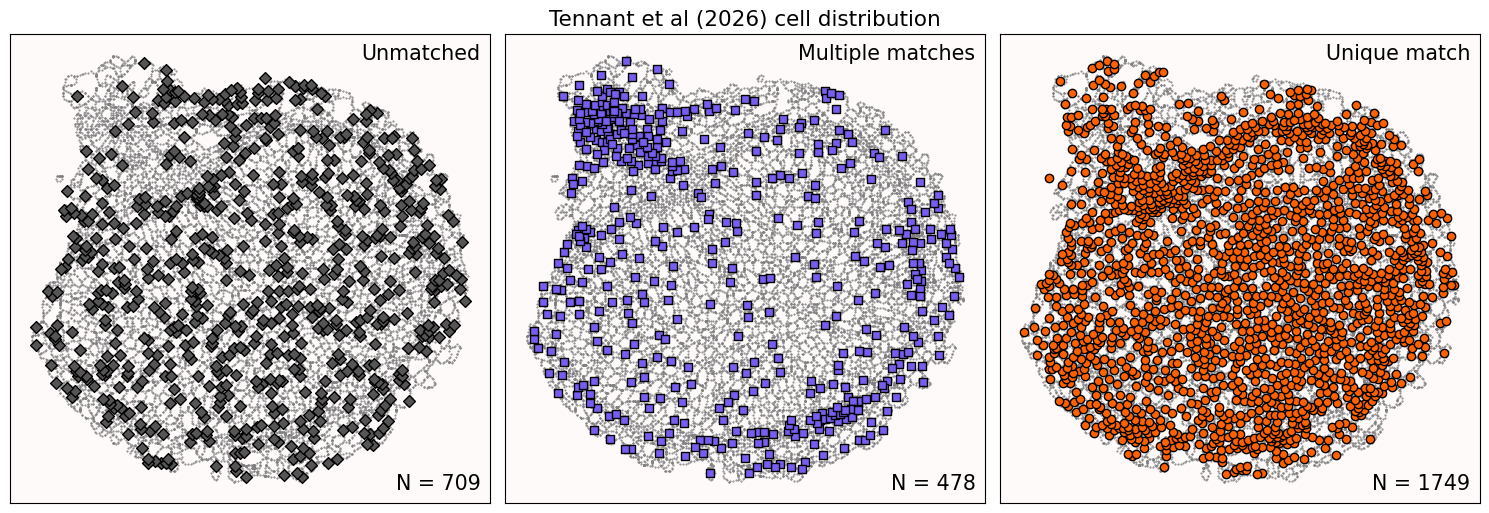

In [185]:
fig,ax = plt.subplots(1,3,figsize=(15,5), sharex=True, sharey=True)

for i in range(len(ax)):
    ax[i].set_facecolor('snow')
    ax[i].scatter(w[1], w[0], marker='.', s=1, c='gray', zorder=1)
    ax[i].text(0.98,.98, idxlabel[i].replace('\n',' '),  transform=ax[i].transAxes, ha='right', va='top', fontsize=1.1*fs)
    ax[i].text(0.98,.02, 'N = {}'.format(len(foo[i])),  transform=ax[i].transAxes, ha='right', va='bottom', fontsize=1.1*fs)

    ax[i].tick_params(**axisoff)
    ax[i].set_aspect('equal')
    ax[i].scatter(*metacell.loc[foo[i], ['ndimage_comX', 'ndimage_comY']].T.values, marker=marker[i],
                  color=wong[i], zorder=2, ec='k', lw=1)
ax[1].set_title(lsutton + ' cell distribution', fontsize=1.15*fs)


fig.tight_layout()
plt.savefig(dst+'matched_cell_location_'+ymethod+fmt, **savefigkw)
plt.savefig(dst+'matched_cell_location_'+ymethod+fmt2, **savefigkw2)

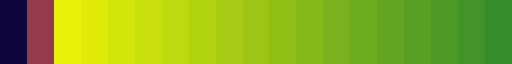

In [167]:
viridis2 = divcmap.resampled(39)
foo = [cmap(i) for i in [0,2]] + [viridis2(i) for i in range(viridis2.N//2-2, 0, -1) ]
cmap2 = mpl.colors.ListedColormap(foo)
cmap2
#viridis2

In [223]:
cidx = 2863
cidx = 2805
bar = matched[matched['putative'] == cidx ].sort_values('IoU')
bar

,putative,TP,FP,FN,IoU,precision,recall,f1
3081,2805,1807,0,249720,0.007184,1.0,0.007184,0.014266
3080,2805,2165,0,249362,0.008607,1.0,0.008607,0.017068


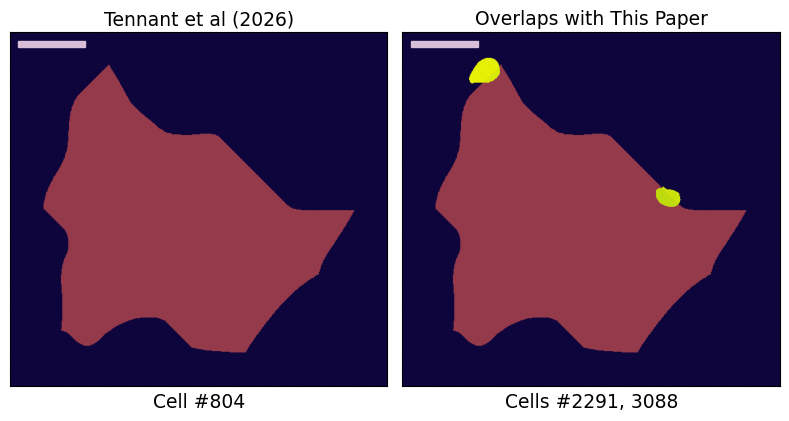

In [141]:
cidx = 803
PP = 50
s_ = (np.s_[max([0, metacell.loc[cidx, 'y0'] - PP]) : min([label.shape[0], metacell.loc[cidx, 'y1'] + PP])],
      np.s_[max([1, metacell.loc[cidx, 'x0'] - PP]) : min([label.shape[1], metacell.loc[cidx, 'x1'] + PP])])
extent = (s_[1].start, s_[1].stop, s_[0].start, s_[0].stop)

bar = matched[matched['putative'] == cidx ]
foo = (label[s_] == cidx).copy().astype(np.uint8)

i = 1
for ix in bar.index:
    foo[ lzw[s_] == ix ] += 2*i
    i += 1

fig, ax = plt.subplots(1,2,figsize=(8,5), sharex=True, sharey=True)
ax[0].set_xlabel('Cell #{}'.format(metacell.loc[cidx, 'orig_cellID']), fontsize=fs)
ax[1].set_xlabel('Cells #' + ', '.join(bar.index.astype(str)), fontsize=fs)
ax[0].imshow(label[s_] == cidx, extent=extent, vmin=0, vmax=cmap2.N, cmap=cmap2)
ax[1].imshow(foo, extent=extent, vmin=0, vmax=cmap2.N, cmap=cmap2)
fig.tight_layout();
title = [lsutton, 'Overlaps with ' + lyaohua]
for i in range(len(ax)):
    ax[i].set_title(title[i], fontsize=fs)
    ax[i].add_artist(AnchoredSizeBar(ax[i].transData, **sbkw1))
    ax[i].tick_params(**axisoff)

fig.tight_layout()
plt.savefig(dst+'nonunique_cell_{:04d}'.format(metacell.loc[cidx, 'orig_cellID'])+fmt, **savefigkw)
plt.savefig(dst+'nonunique_cell_{:04d}'.format(metacell.loc[cidx, 'orig_cellID'])+fmt2, **savefigkw2)

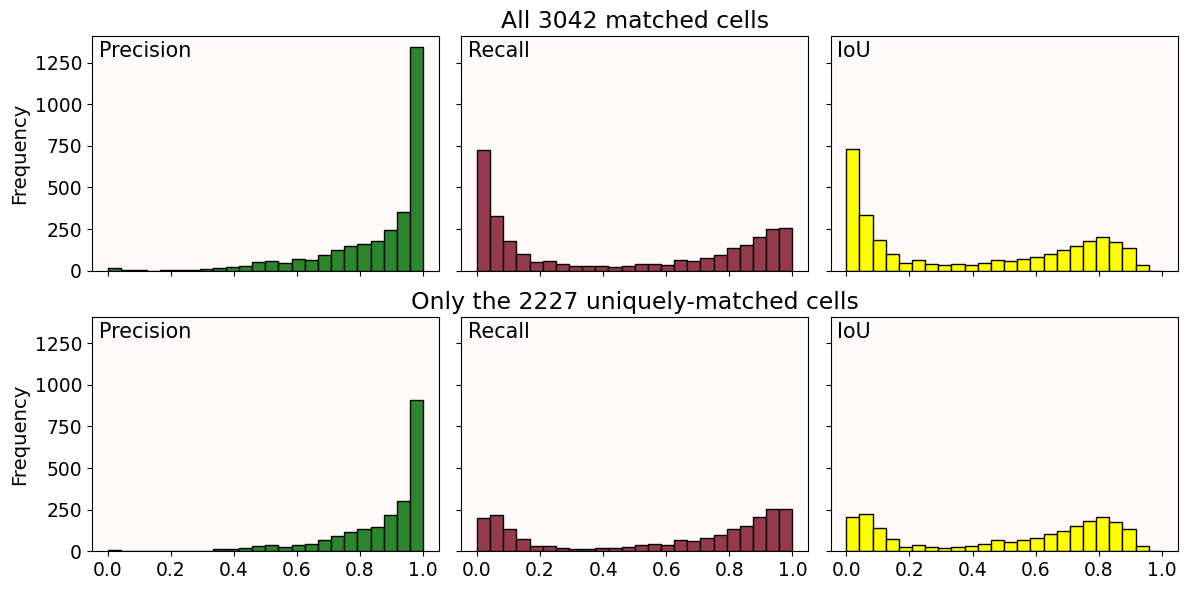

In [144]:
bins = np.linspace(0,1,25)
fig,ax = plt.subplots(2,3,figsize=(12,6), sharex=True, sharey=True)
for i,df in enumerate([matched, nondup]):
    for j,c in enumerate(['precision', 'recall', 'IoU']):
        ax[i,j].set_facecolor('snow')
        ax[i,j].text(0.02,.98, c[0].upper() + c[1:],  transform=ax[i,j].transAxes, ha='left', va='top', fontsize=1.1*fs)
        ax[i,j].hist(df[c], color=cmap(j+1), bins=bins, edgecolor='k')
        ax[i,j].tick_params(labelsize=fs)
    ax[i,0].set_ylabel('Frequency', fontsize=1.05*fs)
ax[0,1].set_title('All {} matched cells'.format(len(matched), ymethod.title()), fontsize=1.25*fs)
ax[1,1].set_title('Only the {} uniquely-matched cells'.format(len(nondup), ymethod.title()), fontsize=1.25*fs)
fig.tight_layout()

plt.savefig(dst + 'value_distribution_' + ymethod + fmt, **savefigkw)
plt.savefig(dst + 'value_distribution_' + ymethod + fmt2, **savefigkw2)

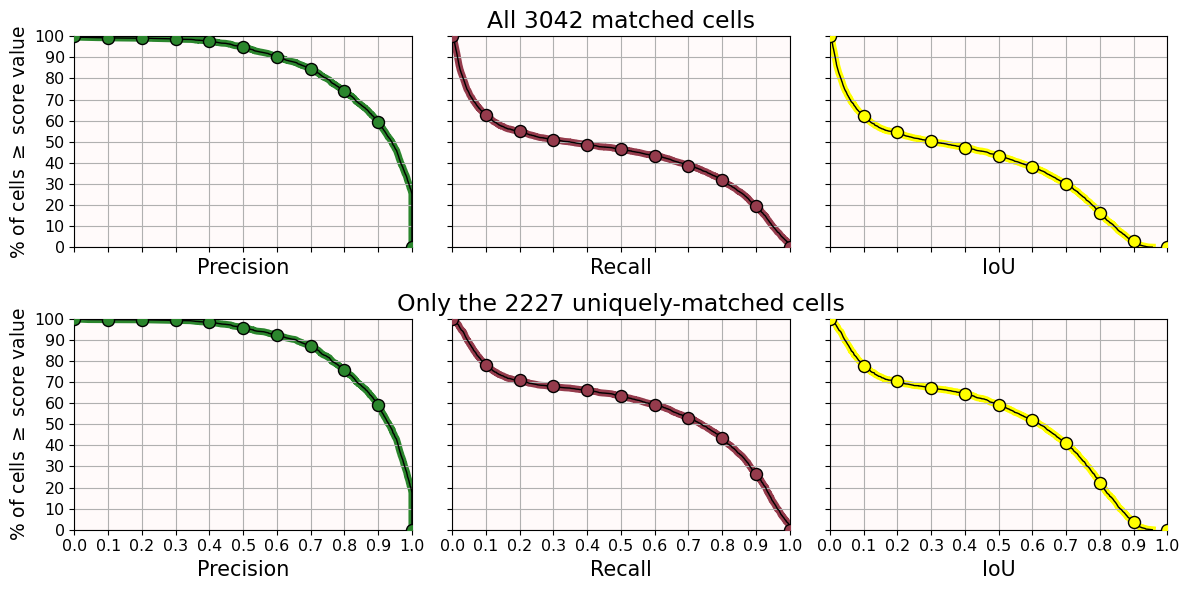

In [145]:
xvals = np.linspace(0,1,11)
fig,ax = plt.subplots(2,3,figsize=(12,6), sharex=True, sharey=True)
for i,df in enumerate([matched, nondup]):
    for j,c in enumerate(['precision', 'recall', 'IoU']):
        ecdf = stats.ecdf(df[c])
        
        ax[i,j].set_facecolor('snow')
        ax[i,j].set_xlabel(c[0].upper() + c[1:], fontsize=1.1*fs)
        ax[i,j].plot(ecdf.cdf.quantiles, 1-ecdf.cdf.probabilities, c=cmap(j+1), lw=5, zorder=1)
        ax[i,j].plot(ecdf.cdf.quantiles, 1-ecdf.cdf.probabilities, c='k', lw=1, zorder=2)
        ax[i,j].scatter(xvals, 1-ecdf.cdf.evaluate(xvals), color=cmap(j+1), ec='k', zorder=3, s=75)
        ax[i,j].tick_params(labelsize=0.85*fs)
        ax[i,j].set_xticks(xvals, np.round(xvals,1) )
        ax[i,j].set_yticks(xvals, np.round(100*xvals,0).astype(int) )
        ax[i,j].grid(which='major')
        ax[i,j].margins(0)
        #ax[i,j].set_xlabel('score value', fontsize=fs)
    ax[i,0].set_ylabel('% of cells $\\geq$ score value', fontsize=fs)
ax[0,1].set_title('All {} matched cells'.format(len(matched), ymethod.title()), fontsize=1.25*fs)
ax[1,1].set_title('Only the {} uniquely-matched cells'.format(len(nondup), ymethod.title()), fontsize=1.25*fs)
fig.tight_layout()

plt.savefig(dst + 'ecdf_value_distribution_' + ymethod + fmt, **savefigkw)
plt.savefig(dst + 'ecdf_value_distribution_' + ymethod + fmt2, **savefigkw2)

In [186]:
df = nondup.copy()
coords = metacell.loc[df['putative'].values, ['ndimage_comX','ndimage_comY']].T.values
scatterkw = dict(x=coords[0], y=coords[1], s=35, zorder=3, ec='k', lw=0.5, alpha=1, cmap=divcmap, vmin=-1, vmax=1)

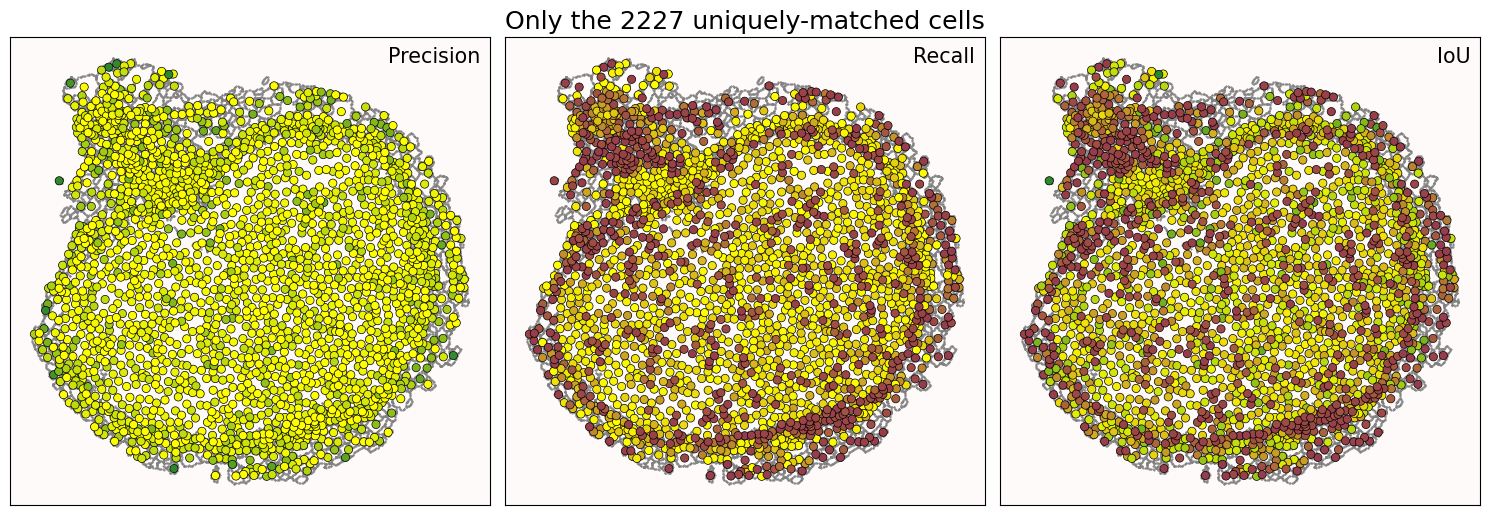

In [194]:
fig,ax = plt.subplots(1,3,figsize=(15,5), sharex=True, sharey=True)

for i,c in enumerate(['precision', 'recall', 'IoU']):
    ax[i].set_facecolor('snow')
    ax[i].scatter(wc[1], wc[0], marker='.', s=1, c='gray', zorder=1)
    ax[i].text(0.98,.98, c[0].upper() + c[1:],  transform=ax[i].transAxes, ha='right', va='top', fontsize=1.1*fs)
    ax[i].tick_params(**axisoff)
    ax[i].set_aspect('equal')
ax[1].set_title('Only the {} uniquely-matched cells'.format(len(nondup), ymethod.title()), fontsize=1.35*fs)

ax[0].scatter(c = -(1-df['precision']), **scatterkw)
#fig.colorbar(mpl.cm.ScalarMappable(cmap=divcmap), ax=ax[0])

ax[1].scatter(c = (1-df['recall']), **scatterkw)
iou = np.sign(df['precision'] - df['recall']) * (1 - df['IoU'])
ax[2].scatter(c = iou, **scatterkw)

fig.tight_layout()
#plt.savefig(dst + 'nodule_distribution_' + ymethod + fmt, **savefigkw)
#plt.savefig(dst + 'nodule_distribution_' + ymethod + fmt2, **savefigkw2)

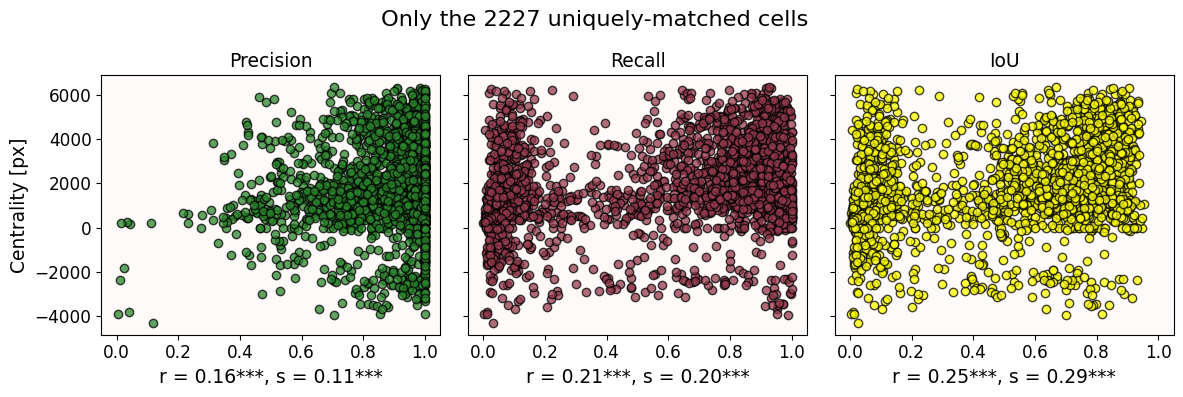

In [153]:
fig,ax = plt.subplots(1,3,figsize=(12,4), sharex=True, sharey=True)
yval = metaecc.loc[ df['putative'].to_numpy(), 'eccentricity']
for i,c in enumerate(['precision', 'recall', 'IoU']):
    pearson = stats.pearsonr(df[c], yval)
    spearman = stats.spearmanr(df[c], yval)

    ax[i].set_facecolor('snow')
    ax[i].set_title(c[0].upper() + c[1:], fontsize=fs)
    ax[i].scatter(df[c], yval, color=cmap(i+1), edgecolor='k', alpha=0.75)
    ax[i].tick_params(labelsize=0.9*fs)
    ll = [pearson.statistic, signifval(pearson.pvalue)*'*', spearman.statistic, signifval(spearman.pvalue)*'*']
    ax[i].set_xlabel('r = {:.2f}{}, s = {:.2f}{}'.format(*ll), fontsize=fs)
ax[0].set_ylabel('Centrality [px]', fontsize=fs)
fig.suptitle('Only the {} uniquely-matched cells'.format(len(nondup), ymethod.title()), fontsize=1.2*fs)
fig.tight_layout()
plt.savefig(dst + 'allcentrality_' + ymethod + fmt, **savefigkw)
plt.savefig(dst + 'allcentrality_' + ymethod + fmt2, **savefigkw2)

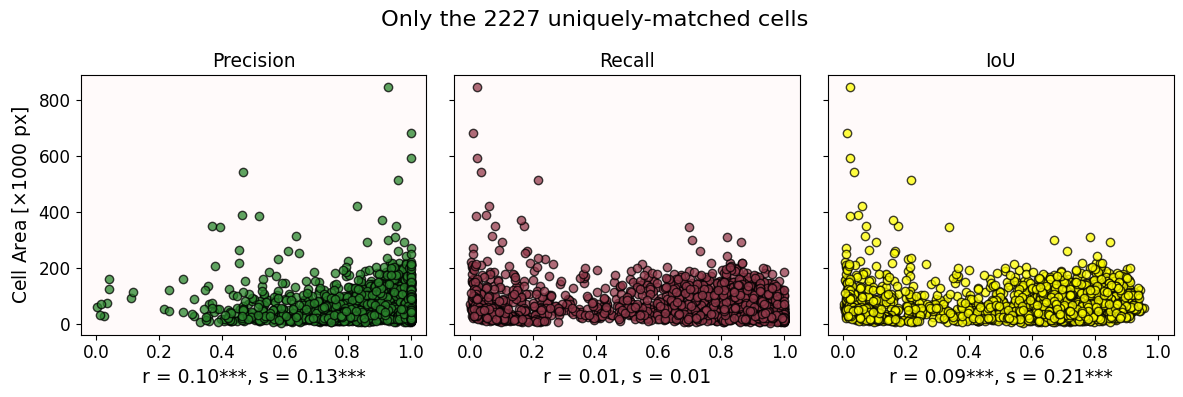

In [198]:
yval = metacell.loc[ df['putative'].to_numpy(), 'total_area']/1000
fig,ax = plt.subplots(1,3,figsize=(12,4), sharex=True, sharey=True)

for i,c in enumerate(['precision', 'recall', 'IoU']):
    pearson = stats.pearsonr( df[c], yval)
    spearman = stats.spearmanr( df[c], yval)

    ax[i].set_facecolor('snow')
    ax[i].set_title(c[0].upper() + c[1:], fontsize=fs)
    ax[i].scatter( df[c], yval, color=cmap(i+1), edgecolor='k', alpha=0.75)
    ax[i].tick_params(labelsize=0.9*fs)
    #ax[i].set_yscale('log',base=10)
    ll = [pearson.statistic, signifval(pearson.pvalue)*'*', spearman.statistic, signifval(spearman.pvalue)*'*']
    ax[i].set_xlabel('r = {:.2f}{}, s = {:.2f}{}'.format(*ll), fontsize=fs)
ax[0].set_ylabel('Cell Area [$\\times$1000 px]', fontsize=fs)
fig.suptitle('Only the {} uniquely-matched cells'.format(len(nondup), ymethod.title()), fontsize=1.2*fs)
fig.tight_layout()
plt.savefig(dst + 'allarea_' + ymethod + fmt, **savefigkw)
plt.savefig(dst + 'allarea_' + ymethod + fmt2, **savefigkw2)

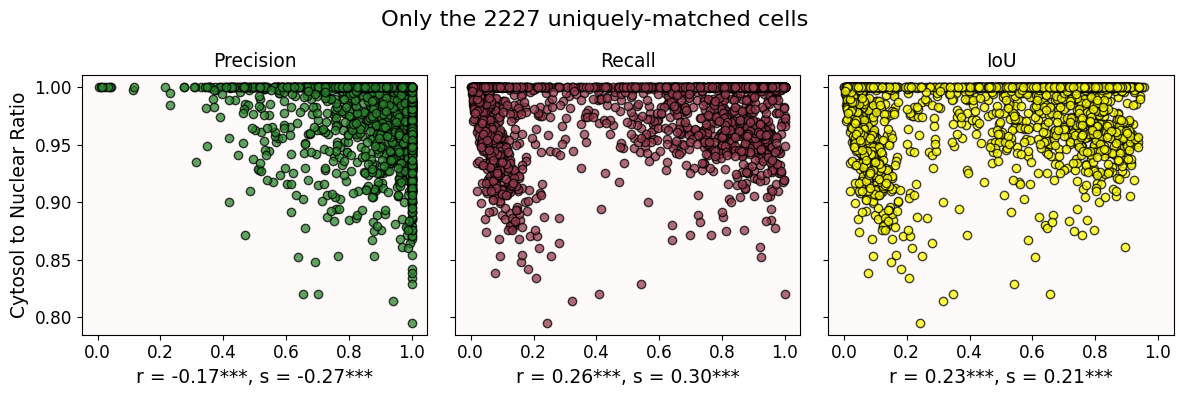

In [155]:
yval = metacell.loc[df['putative'].to_numpy(), 'c2t_area_ratio']
fig,ax = plt.subplots(1,3,figsize=(12,4), sharex=True, sharey=True)

for i,c in enumerate(['precision', 'recall', 'IoU']):
    pearson = stats.pearsonr( df[c], yval)
    spearman = stats.spearmanr( df[c], yval)

    ax[i].set_facecolor('snow')
    ax[i].set_title(c[0].upper() + c[1:], fontsize=fs)
    ax[i].scatter( df[c], yval, color=cmap(i+1), edgecolor='k', alpha=0.75)
    ax[i].tick_params(labelsize=0.9*fs)
    ll = [pearson.statistic, signifval(pearson.pvalue)*'*', spearman.statistic, signifval(spearman.pvalue)*'*']
    ax[i].set_xlabel('r = {:.2f}{}, s = {:.2f}{}'.format(*ll), fontsize=fs)
ax[0].set_ylabel('Cytosol to Nuclear Ratio', fontsize=fs)
fig.suptitle('Only the {} uniquely-matched cells'.format(len(nondup), ymethod.title()), fontsize=1.2*fs)
fig.tight_layout()

plt.savefig(dst + 'allc2nratio_' + ymethod + fmt, **savefigkw)
plt.savefig(dst + 'allc2nratio_' + ymethod + fmt2, **savefigkw2)

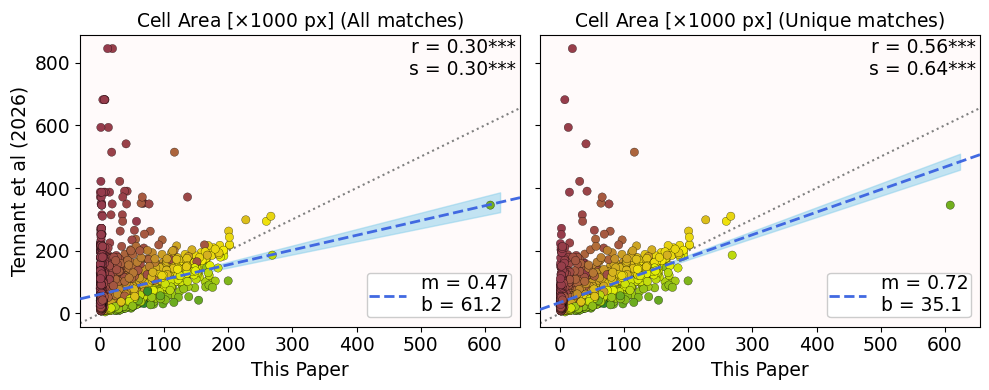

In [171]:
legendkw = dict(framealpha=1, borderpad=0.1, labelspacing=0)#, handletextpad=0, handleheight=0, handlelength=0)
title = ['All matches', 'Unique matches']
fig,ax = plt.subplots(1,2,figsize=(10,4), sharex=True, sharey=True)
x = np.linspace(0, 1.025*newarea[1:].max(), 50)/1000

for i,data in enumerate([matched, nondup]):
    xval = newarea[data.index.to_numpy()]/1000
    yval = metacell.loc[ data['putative'].to_numpy(), 'total_area']/1000
    
    pearson = stats.pearsonr( xval, yval)
    spearman = stats.spearmanr( xval, yval)
    linregress = stats.linregress(xval, yval)
    ll = [pearson.statistic, signifval(pearson.pvalue)*'*', spearman.statistic, signifval(spearman.pvalue)*'*']
    ll = 'r = {:.2f}{}\ns = {:.2f}{}'.format(*ll)
    ax[i].text(0.99,0.99, ll, transform=ax[i].transAxes, ha='right', va='top', fontsize=fs, zorder=5)

    y = linregress.slope * x + linregress.intercept
    t = stats.t.ppf(0.975, len(xval) - 2)
    pred_y = linregress.slope * xval + linregress.intercept
    s = np.sqrt( np.sum( (yval - pred_y)**2)/(len(yval)-2) )
    sy = s * np.sqrt(1/(len(yval)) + ( x - np.mean(xval))**2 / np.sum((xval - np.mean(xval))**2))
    ci = t * sy
    
    ax[i].set_facecolor('snow')
    ax[i].set_title('Cell Area [$\\times$1000 px] (' + title[i] +')', fontsize=fs)
    iou = np.sign(data['precision'] - data['recall']) * (1 - data['IoU'])
    ax[i].scatter(xval, yval, c=iou, cmap=divcmap, ec='k', lw=0.2, vmin=-1, vmax=1, zorder=2)

    ll = 'm = {:.2f}\nb = {:.1f}'.format(linregress.slope, linregress.intercept)
    ax[i].axline( (0, linregress.intercept), slope=linregress.slope, lw=2, ls='dashed', c='royalblue', zorder=3, label=ll)
    ax[i].axline( (0,0), slope=1, ls='dotted', c='gray', zorder=1)
    
    ax[i].set_xlabel(lyaohua, fontsize=fs)
    ax[i].legend(loc='lower right', fontsize = fs, **legendkw)
    ax[i].fill_between(x, y-ci, y+ci, alpha=0.5, color='skyblue', zorder=1);
    ax[i].tick_params(labelsize=fs)

ax[0].set_ylabel(lsutton, fontsize=fs)
fig.tight_layout()
plt.savefig(dst + 'area_comparisons_' + ymethod + fmt, **savefigkw)
plt.savefig(dst + 'area_comparisons_' + ymethod + fmt2, **savefigkw2)

In [176]:
tmatch = dict()

for i,data in enumerate([matched, nondup]):
    t = pd.DataFrame(0, index=data.index, columns=['sutton', 'yaohua'])
    for ix in t.index:
        cidx = data.loc[ix, 'putative']
        t.loc[ix] = [ tsutton[cidx].sum(), tyaohua[ix].sum() ]
    tmatch[title[i]] = t[t.sum(axis = 1) > 0]

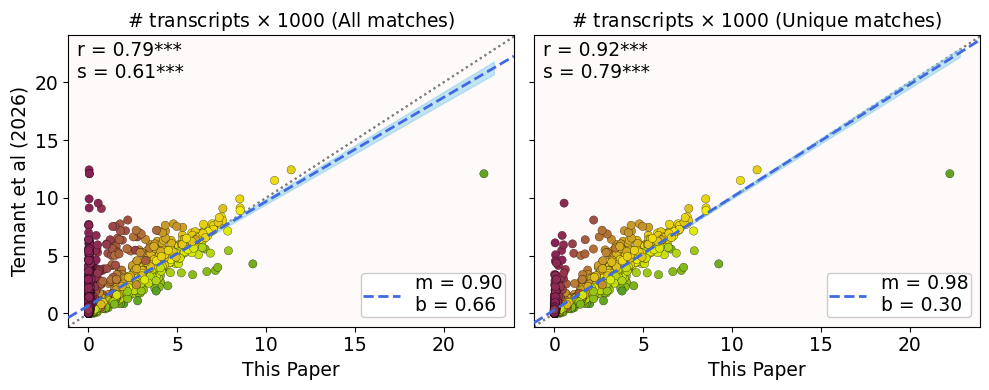

In [192]:
title = ['All matches', 'Unique matches']
fig,ax = plt.subplots(1,2,figsize=(10,4), sharex=True, sharey=True)
x = np.linspace(0, 1.025*tmatch[title[0]]['yaohua'].max()/1000, 50)

for i,data in enumerate([matched, nondup]):    
    xval = tmatch[title[i]]['yaohua']/1000
    yval = tmatch[title[i]]['sutton']/1000
    
    pearson = stats.pearsonr( xval, yval)
    spearman = stats.spearmanr( xval, yval)
    linregress = stats.linregress(xval, yval)
    ll = [pearson.statistic, signifval(pearson.pvalue)*'*', spearman.statistic, signifval(spearman.pvalue)*'*']
    ll = 'r = {:.2f}{}\ns = {:.2f}{}'.format(*ll)
    ax[i].text(0.02,0.98, ll, transform=ax[i].transAxes, ha='left', va='top', fontsize=fs, zorder=5)

    y = linregress.slope * x + linregress.intercept
    t = stats.t.ppf(0.975, len(xval) - 2)
    pred_y = linregress.slope * xval + linregress.intercept
    s = np.sqrt( np.sum( (yval - pred_y)**2)/(len(yval)-2) )
    sy = s * np.sqrt(1/(len(yval)) + ( x - np.mean(xval))**2 / np.sum((xval - np.mean(xval))**2))
    ci = t * sy
    ax[i].axline( (0,0), slope=1, ls='dotted', c='gray', zorder=1);
    
    ax[i].set_facecolor('snow')
    ax[i].set_title('# transcripts $\\times$ 1000 (' + title[i] +')', fontsize=fs)

    iou = np.sign(data.loc[xval.index, 'precision'] - data.loc[xval.index , 'recall']) * (1 - data.loc[xval.index, 'IoU'])
    ax[i].scatter(xval, yval, c=iou, cmap=divcmap, ec='k', lw=0.2, vmin=-1, vmax=1, zorder=2)

    ll = 'm = {:.2f}\nb = {:.2f}'.format(linregress.slope, linregress.intercept)
    ax[i].axline( (0, linregress.intercept), slope=linregress.slope, lw=2, ls='dashed', c='royalblue', zorder=3, label=ll)
    ax[i].axline( (0,0), slope=1, ls='dotted', c='gray', zorder=1)
    
    ax[i].set_xlabel(lyaohua, fontsize=fs)
    ax[i].legend(loc='lower right', fontsize = fs, **legendkw)
    ax[i].fill_between(x, y-ci, y+ci, alpha=0.5, color='skyblue', zorder=1);
    ax[i].tick_params(labelsize=fs)

ax[0].set_ylabel(lsutton, fontsize=fs)
fig.tight_layout()
plt.savefig(dst + 'transcriptcount_comparisons_' + ymethod + fmt, **savefigkw)
plt.savefig(dst + 'transcriptcount_comparisons_' + ymethod + fmt2, **savefigkw2)

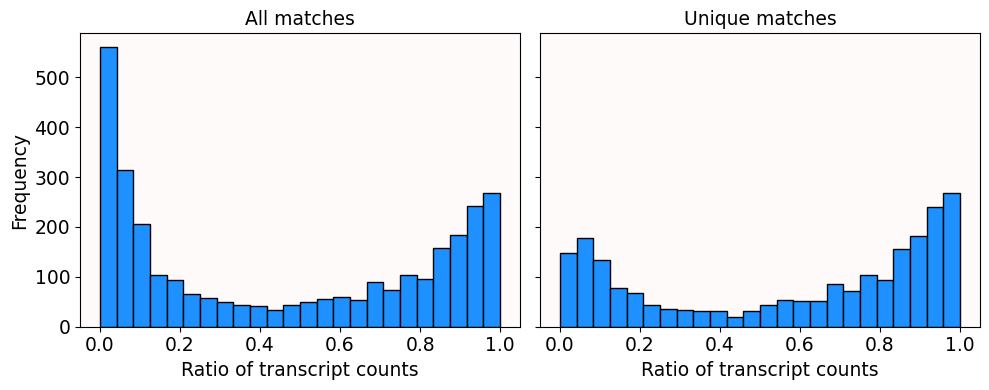

In [193]:
bins = np.linspace(0,1, 25)
fig,ax = plt.subplots(1,2,figsize=(10,4), sharex=True, sharey=True)

for i,data in enumerate([matched, nondup]):    
    xval = tmatch[title[i]]['yaohua']
    yval = tmatch[title[i]]['sutton']
    r = xval / yval
    r = r.where(r <= 1 , yval/xval)
    
    ax[i].set_facecolor('snow')
    ax[i].set_title(title[i], fontsize=fs)
    ax[i].tick_params(labelsize=fs)
    
    ax[i].hist(r , bins, color='dodgerblue', edgecolor='k', zorder=2)

    ax[i].set_xlabel('Ratio of transcript counts'.format(ymethod.title()), fontsize=fs)
ax[0].set_ylabel('Frequency', fontsize=fs)
fig.tight_layout()
plt.savefig(dst + 'transcripthistogram_comparisons_' + ymethod + fmt, **savefigkw)
plt.savefig(dst + 'transcripthistogram_comparisons_' + ymethod + fmt2, **savefigkw2)

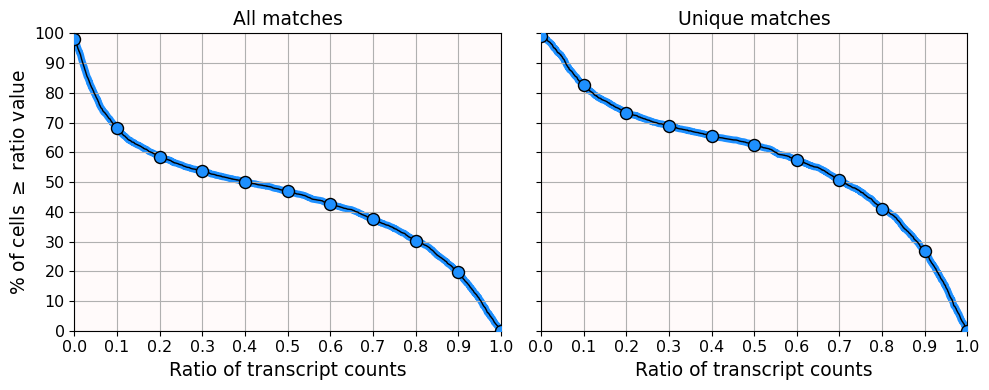

In [202]:
xvals = np.linspace(0,1,11)
fig,ax = plt.subplots(1,2,figsize=(10,4), sharex=True, sharey=True)

for i,data in enumerate([matched, nondup]):    
    xval = tmatch[title[i]]['yaohua']
    yval = tmatch[title[i]]['sutton']
    r = xval / yval
    r = r.where(r <= 1 , yval/xval)
    ecdf = stats.ecdf(r)
    
    ax[i].set_facecolor('snow')
    ax[i].set_title(title[i], fontsize=fs)
    
    ax[i].plot(ecdf.cdf.quantiles, 1-ecdf.cdf.probabilities, c='dodgerblue', lw=5, zorder=1)
    ax[i].plot(ecdf.cdf.quantiles, 1-ecdf.cdf.probabilities, c='k', lw=1, zorder=2)
    ax[i].scatter(xvals, 1-ecdf.cdf.evaluate(xvals), color='dodgerblue', ec='k', zorder=3, s=75)
    ax[i].tick_params(labelsize=0.85*fs)
    ax[i].set_xticks(xvals, np.round(xvals,1) )
    ax[i].set_yticks(xvals, np.round(100*xvals,0).astype(int) )
    ax[i].grid(which='major')
    ax[i].set_xlim(0,1);ax[i].set_ylim(0,1)    
    ax[i].set_xlabel('Ratio of transcript counts', fontsize=fs)

ax[0].set_ylabel('% of cells $\\geq$ ratio value', fontsize=fs)
fig.tight_layout()

plt.savefig(dst + 'ecdf_transcript_distribution_' + ymethod + fmt, **savefigkw)
plt.savefig(dst + 'ecdf_transcript_distribution_' + ymethod + fmt2, **savefigkw2)

In [203]:
tmatches = dict()

for i,data in enumerate([matched, nondup]):
    tmatches[title[i]] = dict()
    for transcript in transcriptomes:
        t = pd.DataFrame(0, index=data.index, columns=['sutton', 'yaohua'])
        for ix in t.index:
            cidx = data.loc[ix, 'putative']
            t.loc[ix] = [ tsutton.loc[transcript , cidx], tyaohua.loc[transcript, ix] ]
        
        tmatches[title[i]][transcript] = t[t.sum(axis = 1) > 0]
    print(title[i])

All matches
Unique matches


In [204]:
t = transcriptomes[26]
tmatches[title[1]][t]
ts = tsutton.sum(axis=1).sort_values(ascending=False).index[:10]
ts

Index(['BAC47034', 'GLYMA_17G195900', 'GLYMA_05G092200', 'BAC52602',
       'GLYMA_12G027400', 'GLYMA_16G039800', 'BAC45727', 'GLYMA_11G008000',
       'GLYMA_05G216000', 'GLYMA_17G185800'],
      dtype='object', name='gene')

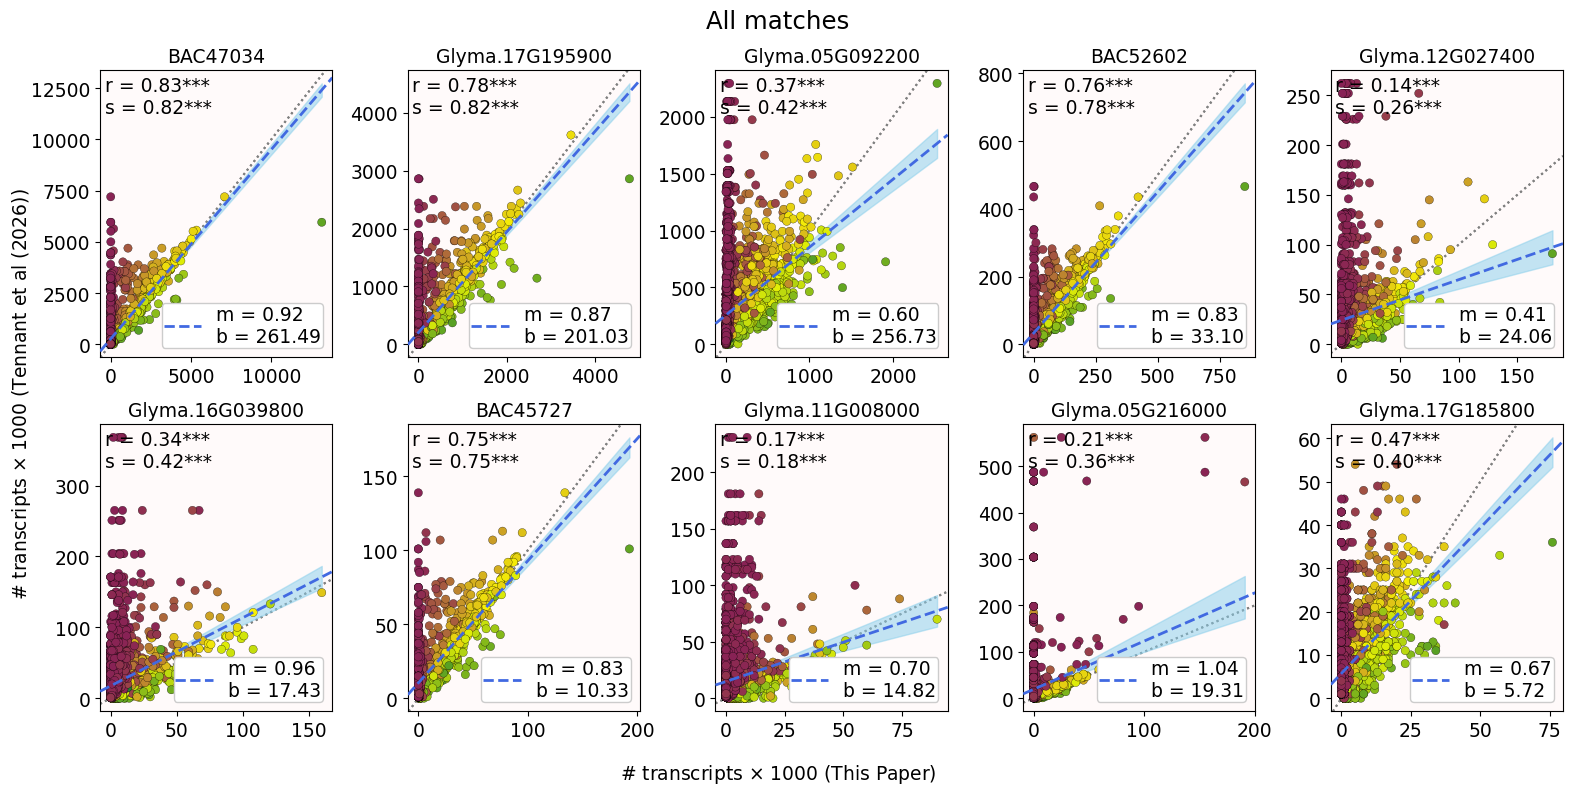

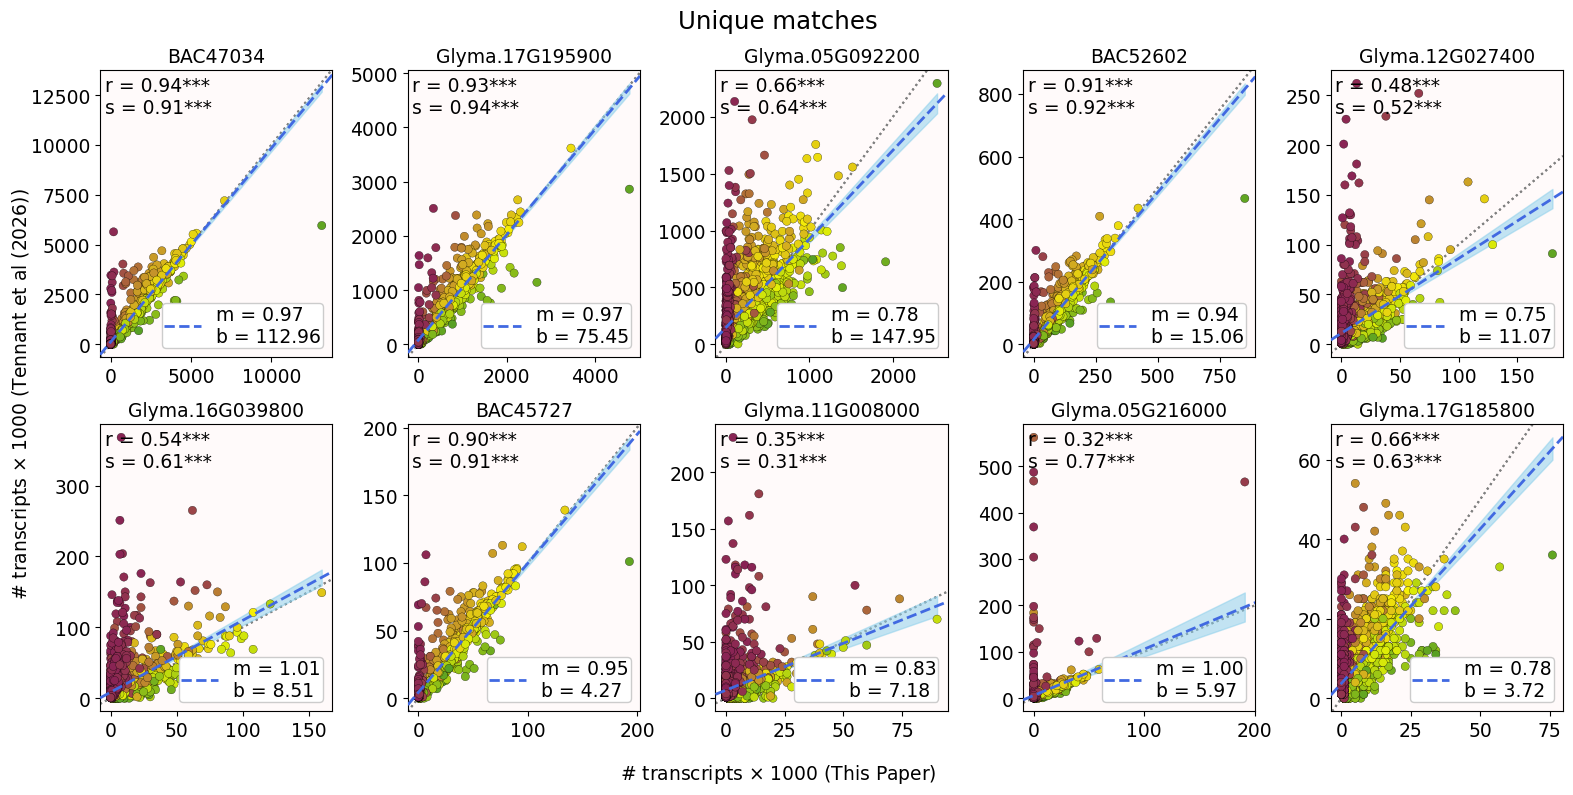

In [207]:
j = 1

for j,data in enumerate([matched, nondup]):
    fig,ax = plt.subplots(2, 5, figsize=(16,8), sharex=False, sharey=False)
    ax = ax.ravel()
    
    for i in range(len(ax)):    
        xval = tmatches[title[j]][ts[i]]['yaohua']
        yval = tmatches[title[j]][ts[i]]['sutton']

        x = np.linspace(0, xval.max(), 50)
        pearson = stats.pearsonr( xval, yval)
        spearman = stats.spearmanr( xval, yval)
        linregress = stats.linregress(xval, yval)
        ll = [pearson.statistic, signifval(pearson.pvalue)*'*', spearman.statistic, signifval(spearman.pvalue)*'*']
        ll = 'r = {:.2f}{}\ns = {:.2f}{}'.format(*ll)
        ax[i].text(0.02,0.98, ll, transform=ax[i].transAxes, ha='left', va='top', fontsize=fs, zorder=5)
    
        y = linregress.slope * x + linregress.intercept
        t = stats.t.ppf(0.975, len(xval) - 2)
        pred_y = linregress.slope * xval + linregress.intercept
        s = np.sqrt( np.sum( (yval - pred_y)**2)/(len(yval)-2) )
        sy = s * np.sqrt(1/(len(yval)) + ( x - np.mean(xval))**2 / np.sum((xval - np.mean(xval))**2))
        ci = t * sy
        ax[i].axline( (0,0), slope=1, ls='dotted', c='gray', zorder=1);
        
        ax[i].set_facecolor('snow')
        ax[i].set_title(ts[i].replace('LYMA_','lyma.'), fontsize=fs)
    
        iou = np.sign(data.loc[xval.index, 'precision'] - data.loc[xval.index , 'recall']) * (1 - data.loc[xval.index, 'IoU'])
        ax[i].scatter(xval, yval, c=iou, cmap=divcmap, ec='k', lw=0.2, vmin=-1, vmax=1, zorder=2)
    
        ll = 'm = {:.2f}\nb = {:.2f}'.format(linregress.slope, linregress.intercept)
        ax[i].axline( (0, linregress.intercept), slope=linregress.slope, lw=2, ls='dashed', c='royalblue', zorder=3, label=ll)
        ax[i].axline( (0,0), slope=1, ls='dotted', c='gray', zorder=1)
        
        ax[i].legend(loc='lower right', fontsize = fs, **legendkw)
        ax[i].fill_between(x, y-ci, y+ci, alpha=0.5, color='skyblue', zorder=1);
        ax[i].tick_params(labelsize=fs)
    
    fig.suptitle(title[j], fontsize=1.3*fs)
    fig.supxlabel('# transcripts $\\times$ 1000 ({})'.format(lyaohua), fontsize=fs)
    fig.supylabel('# transcripts $\\times$ 1000 ({})'.format(lsutton), fontsize=fs)
        
    fig.tight_layout()
    plt.savefig(dst + 'individualgene_comparisons_' + title[j].replace(' ','_').lower() + '_' + ymethod + fmt, **savefigkw)
    plt.savefig(dst + 'individualgene_comparisons_' + title[j].replace(' ','_').lower() + '_' + ymethod + fmt2, **savefigkw2)

----
# Looking at nuclear masks

In [123]:
np.unique(ynuclei)

array([   0,    1,    2, ..., 2235, 2236, 2237], dtype=int32)

In [124]:
matched.loc[ dupidx ]

,putative,TP,FP,FN,IoU,precision,recall,f1
1,12,739,699,28920,0.024343,0.513908,0.024917,0.047529
18,11,502,0,143608,0.003483,1.000000,0.003483,0.006943
3,11,1262,0,142848,0.008757,1.000000,0.008757,0.017362
21,11,1683,0,142427,0.011679,1.000000,0.011679,0.023088
4,16,538,445,87823,0.006058,0.547304,0.006089,0.012043
...,...,...,...,...,...,...,...,...
2207,2863,947,0,178669,0.005272,1.000000,0.005272,0.010489
2202,2863,2764,1965,176852,0.015222,0.584479,0.015388,0.029987
2209,2863,3800,0,175816,0.021156,1.000000,0.021156,0.041436
2212,2884,1316,0,44386,0.028795,1.000000,0.028795,0.055979
